In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import scipy.stats as st
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.3f}'.format) 

sns.set_style("whitegrid")

In [45]:
base_path = Path.cwd().parents[1]  
file_path = base_path / "Notebooks" / "processed_data" / "Dataset_filtered.csv"
df = pd.read_csv(file_path)

In [46]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9537,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977,41.023,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.100,Green,Very Good,788
9538,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041,41.010,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.200,Green,Very Good,1034
9539,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.035,41.056,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.700,Yellow,Good,661
9540,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036,41.058,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.000,Green,Very Good,901


In [47]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [48]:
df = df.drop(labels=['Restaurant Name', 'Address',
       'Locality', 'Locality Verbose', 'Switch to order menu','Rating color', 'Rating text'], axis=1)
df

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,6317637,162,Makati City,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.800,314
1,6304287,162,Makati City,121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.500,591
2,6300002,162,Mandaluyong City,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.400,270
3,6318506,162,Mandaluyong City,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.900,365
4,6314302,162,Mandaluyong City,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.800,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9537,5915730,208,��stanbul,28.977,41.023,Turkish,80,Turkish Lira(TL),No,No,No,3,4.100,788
9538,5908749,208,��stanbul,29.041,41.010,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,3,4.200,1034
9539,5915807,208,��stanbul,29.035,41.056,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,4,3.700,661
9540,5916112,208,��stanbul,29.036,41.058,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,4,4.000,901


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9542 entries, 0 to 9541
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Country Code          9542 non-null   int64  
 2   City                  9542 non-null   object 
 3   Longitude             9542 non-null   float64
 4   Latitude              9542 non-null   float64
 5   Cuisines              9542 non-null   object 
 6   Average Cost for two  9542 non-null   int64  
 7   Currency              9542 non-null   object 
 8   Has Table booking     9542 non-null   object 
 9   Has Online delivery   9542 non-null   object 
 10  Is delivering now     9542 non-null   object 
 11  Price range           9542 non-null   int64  
 12  Aggregate rating      9542 non-null   float64
 13  Votes                 9542 non-null   int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 1.0+ MB


In [50]:
num_cols = [col for col in df.columns if (df[col].dtypes=='int64') or (df[col].dtypes=='float64')]
cat_cols = [col for col in df.columns if col not in num_cols]

print(num_cols,'\n',cat_cols)

['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes'] 
 ['City', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now']


In [51]:
# Separating independent and dependent variables
X = df.drop(labels='Aggregate rating',axis=1)
y = df['Aggregate rating']

In [52]:
X.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
0,6317637,162,Makati City,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,314
1,6304287,162,Makati City,121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,3,591
2,6300002,162,Mandaluyong City,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,270
3,6318506,162,Mandaluyong City,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,365
4,6314302,162,Mandaluyong City,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,229


In [53]:
y[:5]

0   4.800
1   4.500
2   4.400
3   4.900
4   4.800
Name: Aggregate rating, dtype: float64

In [54]:
from sklearn.model_selection import train_test_split

rating_bucket = pd.cut(
    y,
    bins=[-float("inf"), 2.5, 3.5, 4.0, float("inf")],
    labels=["low", "average", "good", "excellent"]
)

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=rating_bucket
    )

In [55]:
print(X_train.shape, y_train.shape)

(7633, 13) (7633,)


In [56]:
print(X_test.shape, y_test.shape)

(1909, 13) (1909,)


In [57]:
# Binary Encoding
binary_mapping = {'No':0, 'Yes':1}

binary_columns = ['Has Table booking', 'Has Online delivery', 'Is delivering now']

for col in binary_columns:
    X_train[col] = X_train[col].replace(binary_mapping)
    X_test[col] = X_test[col].replace(binary_mapping)

X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810
3330,7777,1,New Delhi,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45
8366,18466616,1,Noida,77.312,28.582,"North Indian, Chinese",400,Indian Rupees(Rs.),0,0,0,1,1
3830,18382697,1,New Delhi,77.205,28.694,"Healthy Food, Juices, Salad",250,Indian Rupees(Rs.),0,1,0,1,37
2407,24452,1,Kolkata,88.400,22.549,North Indian,1600,Indian Rupees(Rs.),1,0,0,3,1616


In [58]:
df_train = pd.concat([X_train,y_train], axis=1)
df_test = pd.concat([X_test,y_test], axis=1)

## Encoding City

In [59]:
# Target driven encoding for 'City'

train_rated = df_train[df_train['Aggregate rating']>0]

city_avg_rating_train = (train_rated.groupby(['City'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
city_mapping_train = dict(zip(city_avg_rating_train['City'], city_avg_rating_train['average_rating']))

test_rated = df_test[df_test['Aggregate rating']>0]

city_avg_rating_test = (test_rated.groupby(['City'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
city_mapping_test = dict(zip(city_avg_rating_test['City'], city_avg_rating_test['average_rating']))

In [60]:
X_train['City'] = X_train['City'].replace(city_mapping_train)
X_test['City'] = X_test['City'].replace(city_mapping_test)

X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
796,69024,1,4.300,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810
3330,7777,1,3.302,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45
8366,18466616,1,3.149,77.312,28.582,"North Indian, Chinese",400,Indian Rupees(Rs.),0,0,0,1,1
3830,18382697,1,3.302,77.205,28.694,"Healthy Food, Juices, Salad",250,Indian Rupees(Rs.),0,1,0,1,37
2407,24452,1,4.273,88.400,22.549,North Indian,1600,Indian Rupees(Rs.),1,0,0,3,1616


## Encoding Currency

In [61]:
# Target driven encoding for 'Currency'

train_rated = df_train[df_train['Aggregate rating']>0]

currency_avg_rating_train = (train_rated.groupby(['Currency'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
currency_mapping_train = dict(zip(currency_avg_rating_train['Currency'], currency_avg_rating_train['average_rating']))

test_rated = df_test[df_test['Aggregate rating']>0]

currency_avg_rating_test = (test_rated.groupby(['Currency'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
currency_mapping_test = dict(zip(currency_avg_rating_test['Currency'], currency_avg_rating_test['average_rating']))

In [62]:
X_train['Currency'] = X_train['Currency'].replace(currency_mapping_train)
X_test['Currency'] = X_test['Currency'].replace(currency_mapping_test)

X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
796,69024,1,4.300,80.251,13.006,"European, Italian, Desserts",800,3.352,1,1,0,2,1810
3330,7777,1,3.302,77.206,28.573,"Assamese, Chinese",400,3.352,0,0,0,1,45
8366,18466616,1,3.149,77.312,28.582,"North Indian, Chinese",400,3.352,0,0,0,1,1
3830,18382697,1,3.302,77.205,28.694,"Healthy Food, Juices, Salad",250,3.352,0,1,0,1,37
2407,24452,1,4.273,88.400,22.549,North Indian,1600,3.352,1,0,0,3,1616


## Encoding Country Code

In [63]:
# Target driven encoding for 'Country Code'

train_rated = df_train[df_train['Aggregate rating']>0]

country_avg_rating_train = (train_rated.groupby(['Country Code'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
country_mapping_train = dict(zip(country_avg_rating_train['Country Code'], country_avg_rating_train['average_rating']))

test_rated = df_test[df_test['Aggregate rating']>0]

country_avg_rating_test = (test_rated.groupby(['Country Code'])['Aggregate rating']
                        .agg(average_rating='mean')
                        .sort_values(by='average_rating')
                        .reset_index())
country_mapping_test = dict(zip(country_avg_rating_test['Country Code'], country_avg_rating_test['average_rating']))

In [64]:
X_train['Country Code'] = X_train['Country Code'].replace(country_mapping_train)
X_test['Country Code'] = X_test['Country Code'].replace(country_mapping_test)

X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
796,69024,3.352,4.300,80.251,13.006,"European, Italian, Desserts",800,3.352,1,1,0,2,1810
3330,7777,3.352,3.302,77.206,28.573,"Assamese, Chinese",400,3.352,0,0,0,1,45
8366,18466616,3.352,3.149,77.312,28.582,"North Indian, Chinese",400,3.352,0,0,0,1,1
3830,18382697,3.352,3.302,77.205,28.694,"Healthy Food, Juices, Salad",250,3.352,0,1,0,1,37
2407,24452,3.352,4.273,88.400,22.549,North Indian,1600,3.352,1,0,0,3,1616


## Add cuisine count as an extra numeric feature

In [65]:
X_train["Cuisine_Count"] = X_train["Cuisines"].str.split(", ").apply(len)
X_test["Cuisine_Count"] = X_test["Cuisines"].str.split(", ").apply(len)

X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count
796,69024,3.352,4.300,80.251,13.006,"European, Italian, Desserts",800,3.352,1,1,0,2,1810,3
3330,7777,3.352,3.302,77.206,28.573,"Assamese, Chinese",400,3.352,0,0,0,1,45,2
8366,18466616,3.352,3.149,77.312,28.582,"North Indian, Chinese",400,3.352,0,0,0,1,1,2
3830,18382697,3.352,3.302,77.205,28.694,"Healthy Food, Juices, Salad",250,3.352,0,1,0,1,37,3
2407,24452,3.352,4.273,88.400,22.549,North Indian,1600,3.352,1,0,0,3,1616,1


## Encoding cusines according to rating

In [66]:
# Explode multi-cuisine entries so each row = one cuisine
df_train = (
    df_train.assign(Cuisine=df_train["Cuisines"].str.split(", "))
        .explode("Cuisine")
)
df_train["Cuisine"] = df_train["Cuisine"].str.strip()
df_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Aggregate rating,Cuisine
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,European
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,Italian
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,Desserts
3330,7777,1,New Delhi,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45,2.800,Assamese
3330,7777,1,New Delhi,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45,2.800,Chinese


In [67]:
stats_1 = (
    df_train.groupby("Cuisine")["Aggregate rating"]
            .agg(Avg_Rating="mean")
            .reset_index()
)
cuisine_mapping_train = dict(zip(stats_1['Cuisine'], stats_1['Avg_Rating']))

In [68]:
df_train['Cuisine'] = df_train['Cuisine'].replace(cuisine_mapping_train)
df_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Aggregate rating,Cuisine
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,3.902
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,3.562
796,69024,1,Chennai,80.251,13.006,"European, Italian, Desserts",800,Indian Rupees(Rs.),1,1,0,2,1810,4.200,2.995
3330,7777,1,New Delhi,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45,2.800,2.400
3330,7777,1,New Delhi,77.206,28.573,"Assamese, Chinese",400,Indian Rupees(Rs.),0,0,0,1,45,2.800,2.623


In [69]:
cuisine_rating_train = (
    df_train.groupby("Restaurant ID")['Cuisine']
    .agg(Cuisine_avg_rating='mean')
    .reset_index()
)
cuisine_rating_train

,Restaurant ID,Cuisine_avg_rating
0,53,2.583
1,55,3.114
2,60,2.562
3,64,3.562
4,65,3.355
...,...,...
7628,18499475,2.623
7629,18499482,3.163
7630,18499493,2.561
7631,18500639,2.561


In [70]:
cuisine_rating_train.loc[cuisine_rating_train['Restaurant ID']==69024, 'Cuisine_avg_rating'].squeeze()

np.float64(3.486068305748228)

In [71]:
X_train = pd.merge(X_train, cuisine_rating_train,
                   how='inner',on='Restaurant ID')
X_train.drop('Cuisines', axis=1, inplace=True)
X_train.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,69024,3.352,4.300,80.251,13.006,800,3.352,1,1,0,2,1810,3,3.486
1,7777,3.352,3.302,77.206,28.573,400,3.352,0,0,0,1,45,2,2.512
2,18466616,3.352,3.149,77.312,28.582,400,3.352,0,0,0,1,1,2,2.561
3,18382697,3.352,3.302,77.205,28.694,250,3.352,0,1,0,1,37,3,3.130
4,24452,3.352,4.273,88.400,22.549,1600,3.352,1,0,0,3,1616,1,2.499


In [72]:
# For test data
df_test = (
    df_test.assign(Cuisine=df_test["Cuisines"].str.split(", "))
        .explode("Cuisine")
)
df_test["Cuisine"] = df_test["Cuisine"].str.strip()

stats_2 = (
    df_test.groupby("Cuisine")["Aggregate rating"]
            .agg(Avg_Rating="mean")
            .reset_index()
)
cuisine_mapping_test = dict(zip(stats_2['Cuisine'], stats_2['Avg_Rating']))

df_test['Cuisine'] = df_test['Cuisine'].replace(cuisine_mapping_test)

cuisine_rating_test = (
    df_test.groupby("Restaurant ID")['Cuisine']
    .agg(Cuisine_avg_rating='mean')
    .reset_index()
)
cuisine_rating_test

X_test = pd.merge(X_test, cuisine_rating_test,
                   how='inner',on='Restaurant ID')
X_test.drop('Cuisines', axis=1, inplace=True)
X_test.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,18464618,3.354,3.379,77.100,28.425,400,3.354,0,0,0,1,0,1,2.555
1,18287392,3.354,3.281,77.211,28.641,350,3.354,0,0,0,1,21,1,3.096
2,18458635,3.354,3.379,77.045,28.439,700,3.354,0,0,0,2,0,1,0.000
3,7006421,4.325,4.350,174.763,-36.852,60,4.325,0,0,0,3,414,1,4.014
4,6475,3.354,3.281,77.212,28.537,650,3.354,0,0,0,2,427,3,2.572


In [73]:
X_train.drop('Restaurant ID', axis=1, inplace=True)
X_train

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.352,4.300,80.251,13.006,800,3.352,1,1,0,2,1810,3,3.486
1,3.352,3.302,77.206,28.573,400,3.352,0,0,0,1,45,2,2.512
2,3.352,3.149,77.312,28.582,400,3.352,0,0,0,1,1,2,2.561
3,3.352,3.302,77.205,28.694,250,3.352,0,1,0,1,37,3,3.130
4,3.352,4.273,88.400,22.549,1600,3.352,1,0,0,3,1616,1,2.499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,3.352,3.302,77.102,28.624,350,3.352,0,0,0,1,1,2,2.598
7629,3.352,3.522,73.756,20.013,600,3.352,0,0,0,3,162,3,2.564
7630,3.352,3.302,77.176,28.643,3500,3.352,1,0,0,4,120,1,2.499
7631,3.352,3.320,77.100,28.425,400,3.352,0,0,0,1,0,1,2.623


In [74]:
y_train.reset_index(drop=True, inplace=True)
y_train

0      4.200
1      2.800
2      0.000
3      3.700
4      4.100
        ... 
7628   0.000
7629   3.400
7630   3.400
7631   0.000
7632   3.100
Name: Aggregate rating, Length: 7633, dtype: float64

In [75]:
X_test.drop('Restaurant ID', axis=1, inplace=True)
X_test

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.354,3.379,77.100,28.425,400,3.354,0,0,0,1,0,1,2.555
1,3.354,3.281,77.211,28.641,350,3.354,0,0,0,1,21,1,3.096
2,3.354,3.379,77.045,28.439,700,3.354,0,0,0,2,0,1,0.000
3,4.325,4.350,174.763,-36.852,60,4.325,0,0,0,3,414,1,4.014
4,3.354,3.281,77.212,28.537,650,3.354,0,0,0,2,427,3,2.572
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904,3.354,3.281,77.069,28.628,700,3.354,0,0,0,2,56,2,2.544
1905,3.354,3.281,77.225,28.655,200,3.354,0,0,0,1,30,1,2.548
1906,3.354,3.379,77.018,28.467,300,3.354,0,0,0,1,0,1,2.858
1907,3.354,3.281,77.219,28.709,50,3.354,0,0,0,1,0,1,2.533


In [76]:
y_test.reset_index(drop=True, inplace=True)
y_test

0      0.000
1      3.400
2      0.000
3      4.000
4      3.600
        ... 
1904   3.500
1905   3.700
1906   0.000
1907   0.000
1908   3.300
Name: Aggregate rating, Length: 1909, dtype: float64

In [77]:
num_cols

['Restaurant ID',
 'Country Code',
 'Longitude',
 'Latitude',
 'Average Cost for two',
 'Price range',
 'Aggregate rating',
 'Votes']

In [78]:
num_cols.remove('Restaurant ID')
num_cols.remove('Country Code')
num_cols.remove('Price range')
num_cols.remove('Aggregate rating')
num_cols

['Longitude', 'Latitude', 'Average Cost for two', 'Votes']

## Getting an overview of the numerical features

In [79]:
for col in num_cols:
    print(f"________{col}________")
    print(f"Skewness: {df[col].skew().round(3)}")
    print(f"Kurtosis: {st.kurtosis(df[col], fisher=False).round(3)}")
    print("="*20)
    print("\n")

________Longitude________
Skewness: -2.82
Kurtosis: 11.325


________Latitude________
Skewness: -3.082
Kurtosis: 15.519


________Average Cost for two________
Skewness: 35.461
Kurtosis: 1496.588


________Votes________
Skewness: 8.813
Kurtosis: 131.248




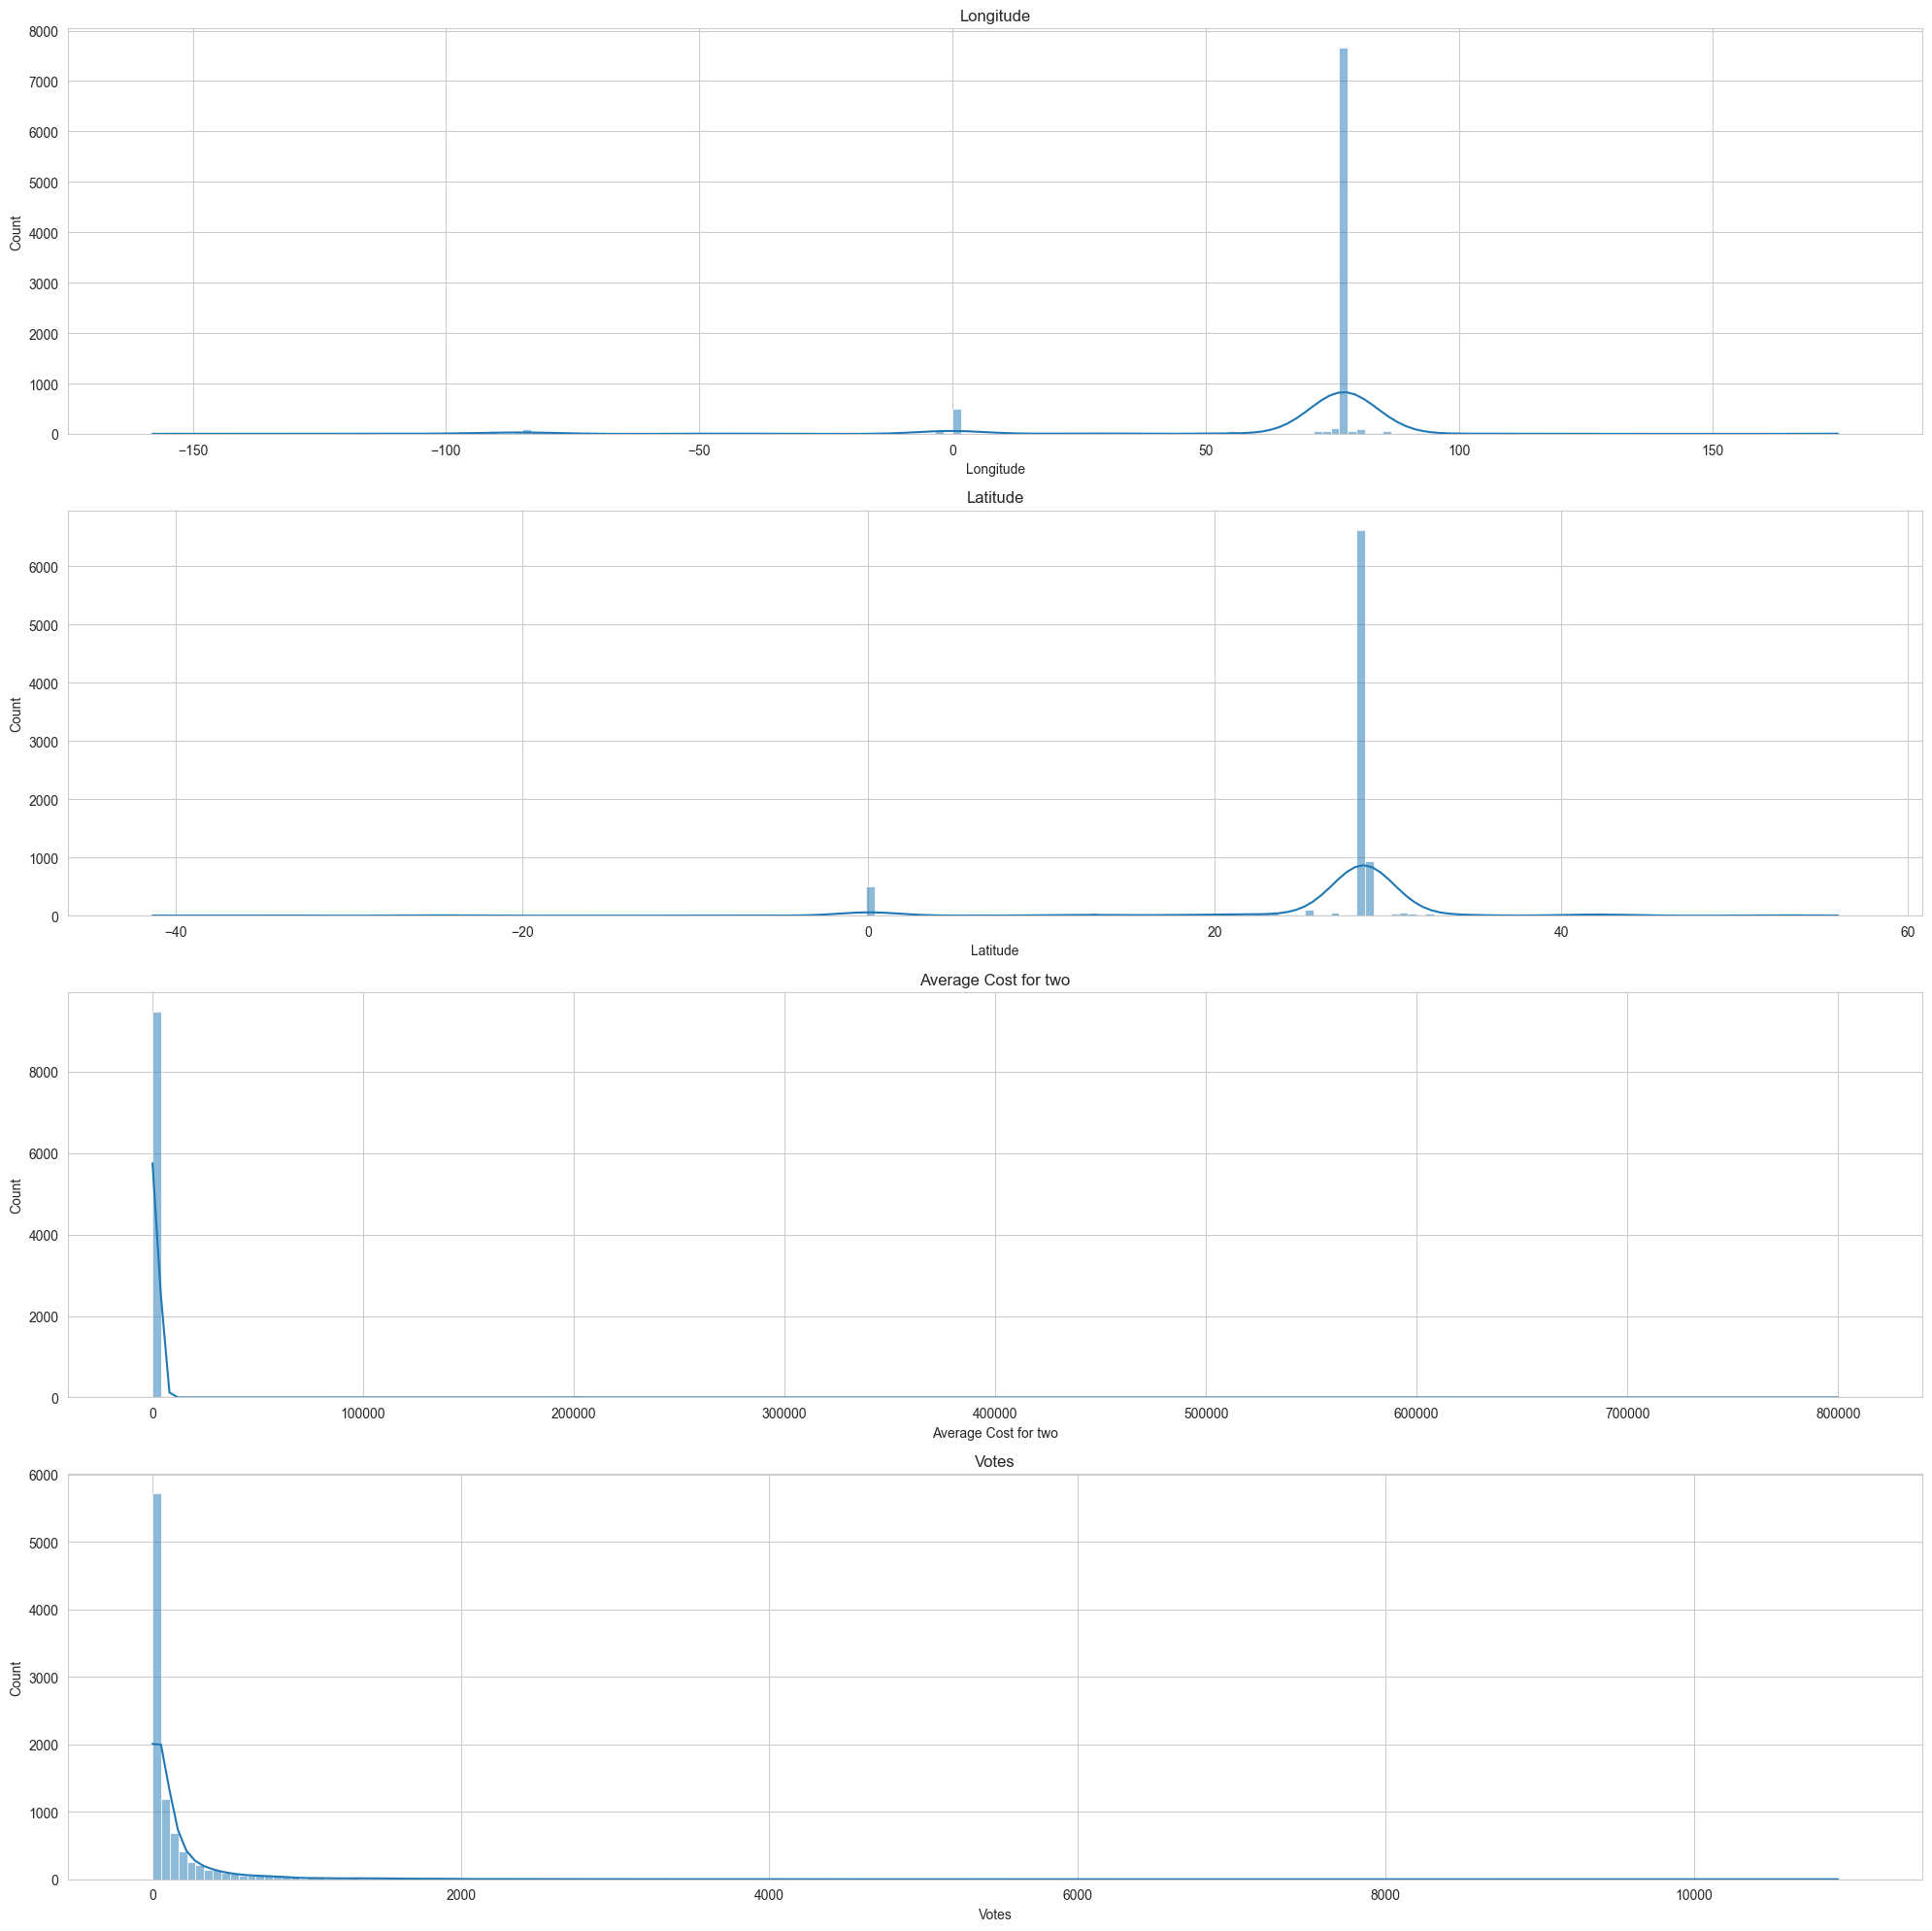

In [80]:
plt.figure(figsize=(20, 5 * len(num_cols)))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Distribution Analysis of numerical features.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight")
plt.show()

**Observation:**
- Votes and Average Cost are highly right-skewed → log1p transform required.

# Correlation Analysis

In [81]:
# Correlation within the input features

corr_value = X_train.corr()
corr_value

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
Country Code,1.000,0.724,-0.593,-0.175,0.158,0.991,-0.047,-0.158,-0.019,0.303,0.140,0.006,0.578
City,0.724,1.000,-0.439,-0.249,0.121,0.717,-0.016,-0.140,-0.021,0.388,0.334,0.100,0.555
Longitude,-0.593,-0.439,1.000,0.039,0.048,-0.557,0.098,0.176,0.019,-0.080,-0.080,0.016,-0.398
Latitude,-0.175,-0.249,0.039,1.000,-0.117,-0.212,0.050,0.115,0.015,-0.175,-0.029,-0.040,-0.116
Average Cost for two,0.158,0.121,0.048,-0.117,1.000,0.159,0.009,-0.020,-0.002,0.079,0.065,0.018,0.112
Currency,0.991,0.717,-0.557,-0.212,0.159,1.000,-0.048,-0.160,-0.020,0.314,0.135,0.008,0.580
Has Table booking,-0.047,-0.016,0.098,0.050,0.009,-0.048,1.000,0.103,-0.017,0.507,0.167,0.227,0.203
Has Online delivery,-0.158,-0.140,0.176,0.115,-0.020,-0.160,0.103,1.000,0.105,0.080,0.071,0.164,-0.000
Is delivering now,-0.019,-0.021,0.019,0.015,-0.002,-0.020,-0.017,0.105,1.000,0.011,-0.003,0.039,-0.015
Price range,0.303,0.388,-0.080,-0.175,0.079,0.314,0.507,0.080,0.011,1.000,0.307,0.316,0.541


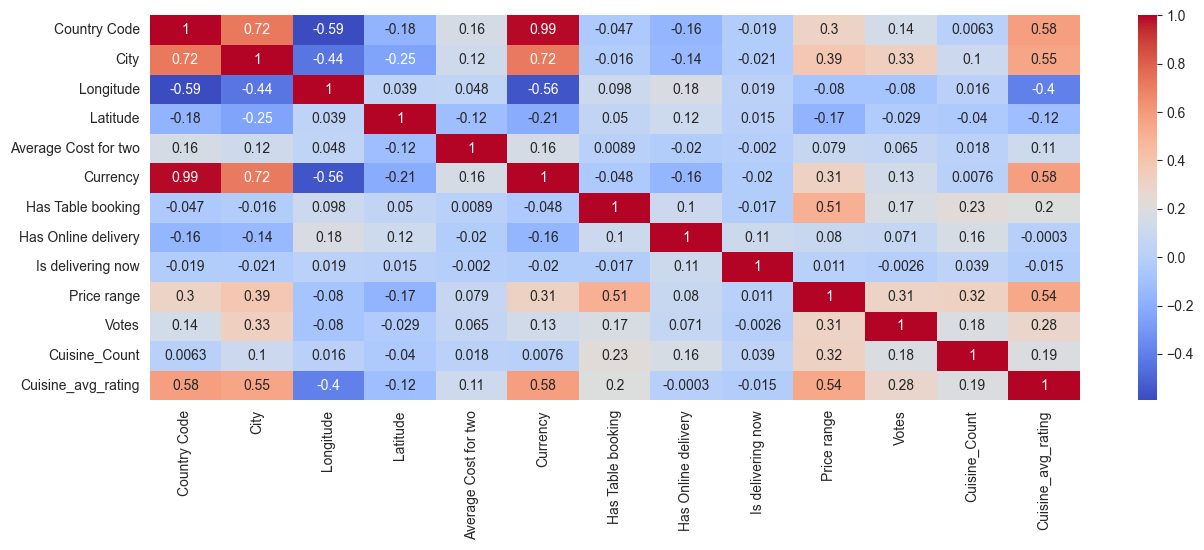

In [82]:
plt.figure(figsize=(15,5))
sns.heatmap(corr_value, annot=True, cmap='coolwarm')
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Inter-correlation_of_input_features.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight");

In [83]:
# Correlation with target 
target = pd.DataFrame(y_train)
corr_value_1 = X_train.corrwith(target['Aggregate rating']).sort_values(ascending=False)
corr_value_1

Price range             0.439
Cuisine_avg_rating      0.423
City                    0.407
Votes                   0.309
Currency                0.291
Country Code            0.291
Cuisine_Count           0.250
Has Online delivery     0.227
Has Table booking       0.189
Average Cost for two    0.056
Is delivering now       0.020
Latitude               -0.002
Longitude              -0.113
dtype: float64

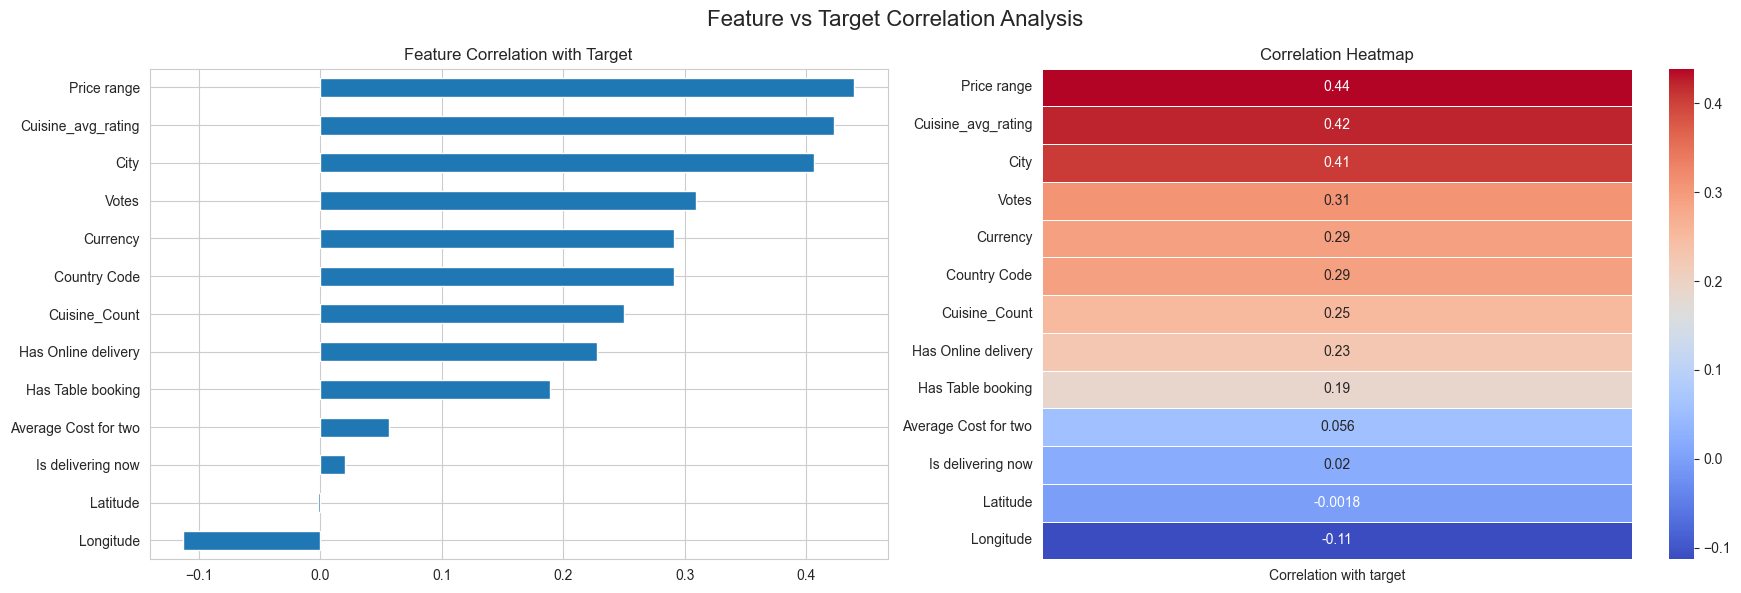

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

corr_value_1[::-1].plot(
    kind='barh',
    ax=axes[0]
)
axes[0].set_title('Feature Correlation with Target')


sns.heatmap(
    corr_value_1.to_frame(name='Correlation with target'),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Correlation Heatmap')


fig.suptitle('Feature vs Target Correlation Analysis', fontsize=16)

plt.tight_layout()
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "correlation_with_target.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight")
plt.show()

# Outlier Detection

In [85]:
df.head()

,Restaurant ID,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,6317637,162,Makati City,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.800,314
1,6304287,162,Makati City,121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.500,591
2,6300002,162,Mandaluyong City,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.400,270
3,6318506,162,Mandaluyong City,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.900,365
4,6314302,162,Mandaluyong City,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.800,229


In [86]:
def detect_outliers(dataset, cols):
    outlier_dict = {}
    for col in cols:
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        upper_whisker = Q3 + (1.5*IQR)
        lower_whisker = Q1 - (1.5*IQR)

        outliers_list = []
        for val in dataset[col]:
            if (val < lower_whisker) or (val > upper_whisker):
                outliers_list.append(val)

        if len(outliers_list) > 0:
            outliers_list.sort()
            outlier_dict[col] = {'Observation': 'Outliers Detected',
                                'Outliers_count': len(outliers_list),
                                 'Lower_Whisker': lower_whisker,
                                 'Upper_Whisker': upper_whisker,
                                'Detected_outliers': outliers_list}
        else:
            outlier_dict[col] = {'Observation': 'No Outliers Detected'}

    return outlier_dict

In [87]:
req_cols = ['Average Cost for two','Aggregate rating','Votes']
result = detect_outliers(df, req_cols)
for key, value in result.items():
    print(f"__________{key}__________\n{value}")

__________Average Cost for two__________
{'Observation': 'Outliers Detected', 'Outliers_count': 853, 'Lower_Whisker': np.float64(-425.0), 'Upper_Whisker': np.float64(1375.0), 'Detected_outliers': [1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1400, 1450, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500,

## Log transformation:

In [88]:
cols = ['Average Cost for two','Votes']
for col in cols:
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col] = np.log1p(X_test[col].clip(lower=0))

In [89]:
X_train

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.352,4.300,80.251,13.006,6.686,3.352,1,1,0,2,7.502,3,3.486
1,3.352,3.302,77.206,28.573,5.994,3.352,0,0,0,1,3.829,2,2.512
2,3.352,3.149,77.312,28.582,5.994,3.352,0,0,0,1,0.693,2,2.561
3,3.352,3.302,77.205,28.694,5.525,3.352,0,1,0,1,3.638,3,3.130
4,3.352,4.273,88.400,22.549,7.378,3.352,1,0,0,3,7.388,1,2.499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,3.352,3.302,77.102,28.624,5.861,3.352,0,0,0,1,0.693,2,2.598
7629,3.352,3.522,73.756,20.013,6.399,3.352,0,0,0,3,5.094,3,2.564
7630,3.352,3.302,77.176,28.643,8.161,3.352,1,0,0,4,4.796,1,2.499
7631,3.352,3.320,77.100,28.425,5.994,3.352,0,0,0,1,0.000,1,2.623


## Normalization

- Among MinMaxScaler, StandardScaler & RobustScaler we are going to use RobustScaler because RobustScaler uses median + IQR, making it immune to those extremes.

In [90]:
from sklearn.preprocessing import RobustScaler

cols = ['Longitude', 'Latitude', 'Average Cost for two', 'Votes']
scaler = RobustScaler()
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [91]:
X_train.head()

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.352,4.300,15.227,-94.440,0.674,3.352,1,1,0,2,1.306,3,3.486
1,3.352,3.302,0.070,0.016,0.000,3.352,0,0,0,1,0.117,2,2.512
2,3.352,3.149,0.598,0.072,0.000,3.352,0,0,0,1,-0.897,2,2.561
3,3.352,3.302,0.063,0.752,-0.456,3.352,0,1,0,1,0.056,3,3.130
4,3.352,4.273,55.801,-36.535,1.348,3.352,1,0,0,3,1.269,1,2.499


In [92]:
X_test.head()

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.354,3.379,-0.461,-0.880,0.000,3.354,0,0,0,1,-1.121,1,2.555
1,3.354,3.281,0.095,0.426,-0.130,3.354,0,0,0,1,-0.121,1,3.096
2,3.354,3.379,-0.733,-0.795,0.544,3.354,0,0,0,2,-1.121,1,0.000
3,4.325,4.350,485.763,-396.955,-1.833,4.325,0,0,0,3,0.829,1,4.014
4,3.354,3.281,0.100,-0.205,0.472,3.354,0,0,0,2,0.839,3,2.572


# Final Check

In [93]:
X_train.head()

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Cuisine_Count,Cuisine_avg_rating
0,3.352,4.300,15.227,-94.440,0.674,3.352,1,1,0,2,1.306,3,3.486
1,3.352,3.302,0.070,0.016,0.000,3.352,0,0,0,1,0.117,2,2.512
2,3.352,3.149,0.598,0.072,0.000,3.352,0,0,0,1,-0.897,2,2.561
3,3.352,3.302,0.063,0.752,-0.456,3.352,0,1,0,1,0.056,3,3.130
4,3.352,4.273,55.801,-36.535,1.348,3.352,1,0,0,3,1.269,1,2.499


In [94]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7633 entries, 0 to 7632
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          7633 non-null   float64
 1   City                  7633 non-null   float64
 2   Longitude             7633 non-null   float64
 3   Latitude              7633 non-null   float64
 4   Average Cost for two  7633 non-null   float64
 5   Currency              7633 non-null   float64
 6   Has Table booking     7633 non-null   int64  
 7   Has Online delivery   7633 non-null   int64  
 8   Is delivering now     7633 non-null   int64  
 9   Price range           7633 non-null   int64  
 10  Votes                 7633 non-null   float64
 11  Cuisine_Count         7633 non-null   int64  
 12  Cuisine_avg_rating    7633 non-null   float64
dtypes: float64(8), int64(5)
memory usage: 775.4 KB


In [95]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1909 entries, 0 to 1908
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          1909 non-null   float64
 1   City                  1909 non-null   float64
 2   Longitude             1909 non-null   float64
 3   Latitude              1909 non-null   float64
 4   Average Cost for two  1909 non-null   float64
 5   Currency              1909 non-null   float64
 6   Has Table booking     1909 non-null   int64  
 7   Has Online delivery   1909 non-null   int64  
 8   Is delivering now     1909 non-null   int64  
 9   Price range           1909 non-null   int64  
 10  Votes                 1909 non-null   float64
 11  Cuisine_Count         1909 non-null   int64  
 12  Cuisine_avg_rating    1909 non-null   float64
dtypes: float64(8), int64(5)
memory usage: 194.0 KB


In [96]:
float_cols = ['City','Currency','Cuisine_avg_rating']
int_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']

for col in float_cols:
    X_train[col] = X_train[col].astype('float64')
    X_test[col] = X_test[col].astype('float64')

for col in int_cols:
    X_train[col] = X_train[col].astype('int64')
    X_test[col] = X_test[col].astype('int64')

In [97]:
print(X_train.info())
print()
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7633 entries, 0 to 7632
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          7633 non-null   float64
 1   City                  7633 non-null   float64
 2   Longitude             7633 non-null   float64
 3   Latitude              7633 non-null   float64
 4   Average Cost for two  7633 non-null   float64
 5   Currency              7633 non-null   float64
 6   Has Table booking     7633 non-null   int64  
 7   Has Online delivery   7633 non-null   int64  
 8   Is delivering now     7633 non-null   int64  
 9   Price range           7633 non-null   int64  
 10  Votes                 7633 non-null   float64
 11  Cuisine_Count         7633 non-null   int64  
 12  Cuisine_avg_rating    7633 non-null   float64
dtypes: float64(8), int64(5)
memory usage: 775.4 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1909 entries, 0 to 1

## Model Training

In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [99]:
##Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [100]:
## Defining Base Models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "GradientBoost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": XGBRegressor()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print('          ',list(models.keys())[i],'          ')
    print()
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('-'*35)
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

           Linear Regression           

Model performance for Training set
- Root Mean Squared Error: 0.7957
- Mean Absolute Error: 0.6750
- R2 Score: 0.7250
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7912
- Mean Absolute Error: 0.6778
- R2 Score: 0.7267


           Lasso           

Model performance for Training set
- Root Mean Squared Error: 1.5075
- Mean Absolute Error: 1.2129
- R2 Score: 0.0128
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.5024
- Mean Absolute Error: 1.2092
- R2 Score: 0.0147


           Ridge           

Model performance for Training set
- Root Mean Squared Error: 0.7957
- Mean Absolute Error: 0.6751
- R2 Score: 0.7250
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7912
- Mean Absolute Error: 0.6778
- R2 Score: 0.7267


           K-Neighbors Regressor           

Model performance for Training set
- Root Mean

### After considering all above models we ar going to choose GradientBoost, Random Forest and XGBoost for hyper parameter tunning

# Hyperparameter Tunning with Random Search CV

In [64]:
#Initialize few parameter for Hyperparamter tuning

gradient_params = {"loss": ['squared_error','huber','absolute_error'],
             "criterion": ['friedman_mse','squared_error','mse'],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500],
              "max_depth": [5, 8, 15, None, 10],
               "learning_rate": [0.1, 0.01, 0.02, 0.03]
            }

rforest_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300, 500, 1000],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [65]:
# Models list for Hyperparameter tuning
randomcv_models = [("GB", GradientBoostingRegressor(), gradient_params),
                   ("RF", RandomForestRegressor(), rforest_params),
                   ("XB", XGBRegressor(), xgboost_params),
                   ]

In [66]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=5,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
---------------- Best Params for GB -------------------
{'n_estimators': 500, 'min_samples_split': 15, 'max_depth': 5, 'loss': 'squared_error', 'learning_rate': 0.03, 'criterion': 'friedman_mse'}
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 5, 'max_depth': 15}
---------------- Best Params for XB -------------------
{'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1}


In [68]:
# Retraining the models with best parameters
models = {
    "GradientBoost Regressor": GradientBoostingRegressor(n_estimators=500, min_samples_split=15,
                                                        loss='squared_error', learning_rate=0.03, criterion='friedman_mse'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=500,min_samples_split=2,
                                                     max_features=5,max_depth=15,n_jobs=-1),
    "XGBoost Regressor": XGBRegressor(n_estimators=1000,max_depth=5,learning_rate=0.01,cosample_bytree=1,n_jobs=-1)
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print('          ',list(models.keys())[i],'          ')
    print()
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('-'*35)
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

           GradientBoost Regressor           

Model performance for Training set
- Root Mean Squared Error: 0.2873
- Mean Absolute Error: 0.1889
- R2 Score: 0.9641
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2932
- Mean Absolute Error: 0.1953
- R2 Score: 0.9625


           Random Forest Regressor           

Model performance for Training set
- Root Mean Squared Error: 0.1736
- Mean Absolute Error: 0.1134
- R2 Score: 0.9869
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2944
- Mean Absolute Error: 0.2006
- R2 Score: 0.9622


           XGBoost Regressor           

Model performance for Training set
- Root Mean Squared Error: 0.2691
- Mean Absolute Error: 0.1744
- R2 Score: 0.9685
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2907
- Mean Absolute Error: 0.1914
- R2 Score: 0.9631




### After considering the above performace we can finalize XGBoost as the model.

In [69]:
final_model = XGBRegressor(n_estimators=1000,max_depth=5,learning_rate=0.01,cosample_bytree=1,n_jobs=-1)

final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes